# Palm-Based Anemia Detection — Reproducing Four Research Papers

This notebook implements a **non-invasive anemia detection pipeline from palm images**, faithfully
reproducing the computer-vision and machine-learning methodologies described in the four papers in
`paper/`.

## Papers implemented

| # | Paper | Key contributions reproduced here |
|---|-------|------------------------------------|
| **P1** | Kesarwani *et al.*, *"Non-invasive anaemia detection by examining palm pallor"*, **Biomedical Signal Processing and Control** 79 (2023) 104045 | ROI extraction, palm-pallor colour-channel analysis, **ensemble** prediction models (Sensitivity 93%) |
| **P2** | Keneshlou *et al.*, *"Machine-Learning-Based Non-Invasive Diagnosis of Anemia in Children Using Palm Image Analysis"*, **medRxiv** 2026 | Segmentation, **RGB / CIELab / HSV** colour features, **red fraction, erythema index, normalized-a**, Logistic-Regression / Gradient-Boosting / CNN (≈94–95%), histogram-equalisation & white-balance pre-processing |
| **P3** | Rizal *et al.*, *"Detecting Anemia Based on Palm Images using CNN"*, **IJAERS** 9(9) 2022 | Palm-image classification, RGB channels, CNN/neural baseline (Acc 96.43%, Recall 100%, Specificity 92.86%) |
| **P4** | Appiahene *et al.*, *"Detection of iron deficiency anemia by medical images: a comparative study of ML algorithms"*, **BioData Mining** 16:2 (2023) | **This is the source dataset used here** (Ghana palm images, augmented via rotation/flip/translation). ROI segmentation, **CIE L\*a\*b\*** features, comparative ML (CNN, k-NN, Naïve-Bayes, SVM, Decision-Tree; NB 99.96%, SVM 96.34%) |

## Pipeline overview
1. **Dataset loading & labelling** — parse `AnemicP` / `Non-AnemicP` filenames → binary labels.
2. **Image enhancement** — CLAHE, Gamma correction, Histogram Equalisation, Bilateral & Gaussian filtering, white-balance *(P2, P4)*.
3. **Segmentation & ROI extraction** — HSV + YCbCr skin thresholding, Otsu thresholding, contour detection *(P1, P2, P4)*.
4. **Feature extraction** — colour statistics (Mean / Std / Skewness) across **RGB, HSV, CIELab, YCbCr**, plus pallor-specific indices (red fraction, erythema, normalized-a), and **texture** via **GLCM** and **LBP** *(P2, P4)*.
5. **Classification** — SVM, Random Forest, KNN, XGBoost, Logistic Regression, Gradient Boosting, Naïve Bayes, Decision Tree, MLP neural net *(P2, P3, P4)*.
6. **Evaluation** — Accuracy, Sensitivity, Specificity, ROC-AUC, confusion matrices, ROC curves, plus a **subject-grouped (leakage-aware)** validation.


## 0 · Environment & Imports

In [1]:
import os, glob, re, time, warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern

from sklearn.model_selection import train_test_split, GroupShuffleSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, roc_auc_score,
                             roc_curve, classification_report, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

DATA_DIR = "/Users/nareswari/Downloads/Palm"
IMG_SIZE = (128, 128)   # working resolution for feature extraction
print("OpenCV:", cv2.__version__)
print("Dataset exists:", os.path.isdir(DATA_DIR))

OpenCV: 5.0.0
Dataset exists: True


## 1 · Dataset Loading & Labelling

The dataset (Appiahene *et al.*, **P4**) is a flat folder of `.png` palm images. Two classes are
encoded in the filenames:

* **Anemic** — `AnemicP-*`, `Anemic-*`, `Anemic-Pa-*`  → label **1** (positive)
* **Non-anemic** — `Non-AnemicP-*`, `Non-anemic-Pa-*` → label **0** (negative)

The parenthesised suffix `(2)…(12)` marks the augmented copies (rotation / flip / translation) of the
same subject. We also extract a **subject ID** so we can later run a *leakage-aware* subject-grouped
split.

In [2]:
paths = sorted(glob.glob(os.path.join(DATA_DIR, "*.png")))
print(f"Total images found: {len(paths)}")

def parse(fname):
    base = os.path.basename(fname)
    is_non = base.lower().startswith("non")          # 'Non-AnemicP' / 'Non-anemic-Pa'
    label = 0 if is_non else 1                        # 1 = Anemic, 0 = Non-anemic
    # subject id = filename without the augmentation "(n)" suffix and extension
    subj = re.sub(r"\s*\(\d+\)", "", base)
    subj = os.path.splitext(subj)[0]
    return label, subj

records = []
for p in paths:
    lbl, subj = parse(p)
    records.append({"path": p, "label": lbl, "subject": subj})

df = pd.DataFrame(records)
df["class_name"] = df["label"].map({1: "Anemic", 0: "Non-anemic"})
print(df["class_name"].value_counts())
print("Unique subjects:", df["subject"].nunique())
df.head()

Total images found: 4260
class_name
Anemic        2562
Non-anemic    1698
Name: count, dtype: int64
Unique subjects: 528


,path,label,subject,class_name
0,/Users/nareswari/Downloads/Palm/Anemic-260 (10...,1,Anemic-260,Anemic
1,/Users/nareswari/Downloads/Palm/Anemic-260 (11...,1,Anemic-260,Anemic
2,/Users/nareswari/Downloads/Palm/Anemic-260 (12...,1,Anemic-260,Anemic
3,/Users/nareswari/Downloads/Palm/Anemic-260 (2)...,1,Anemic-260,Anemic
4,/Users/nareswari/Downloads/Palm/Anemic-260 (3)...,1,Anemic-260,Anemic


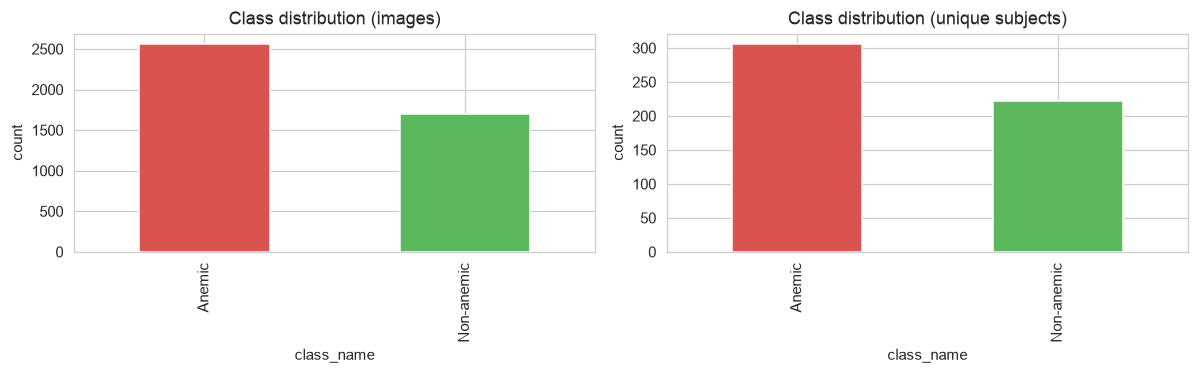

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
df["class_name"].value_counts().plot.bar(ax=ax[0], color=["#d9534f", "#5cb85c"])
ax[0].set_title("Class distribution (images)"); ax[0].set_ylabel("count")
df.drop_duplicates("subject")["class_name"].value_counts().plot.bar(ax=ax[1], color=["#d9534f", "#5cb85c"])
ax[1].set_title("Class distribution (unique subjects)"); ax[1].set_ylabel("count")
plt.tight_layout(); plt.show()

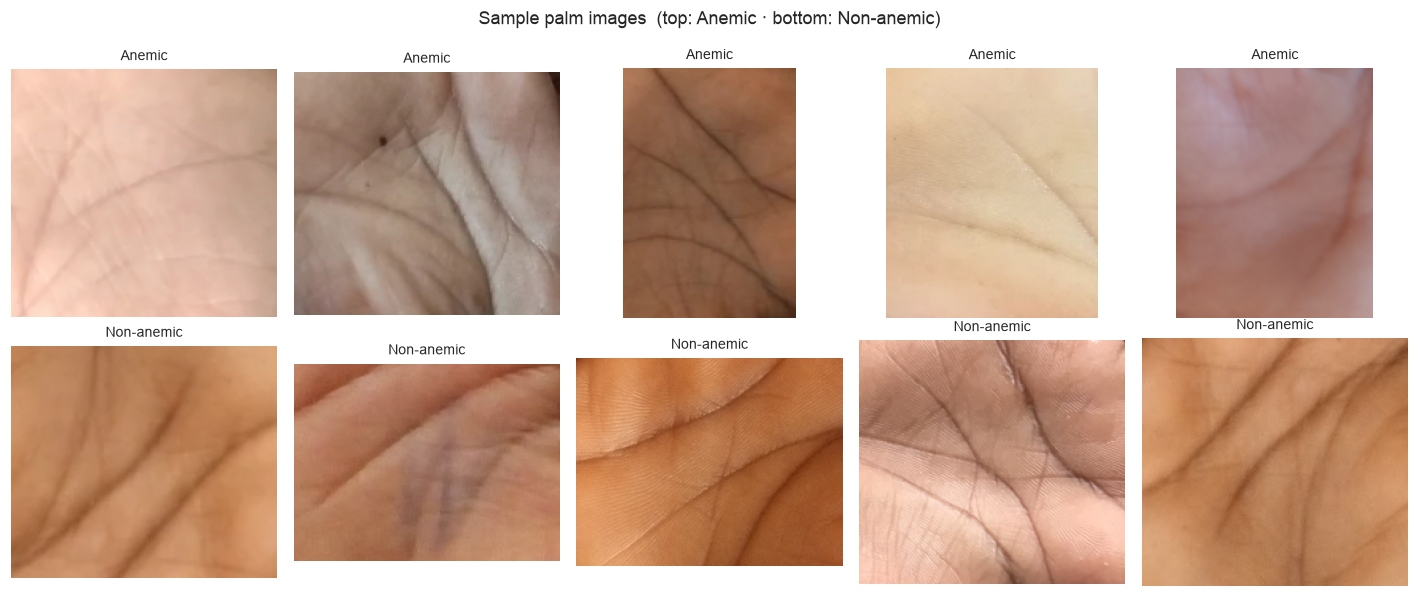

In [4]:
# Preview a few palm images from each class
fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
for r, cls in enumerate([1, 0]):
    sub = df[df.label == cls].sample(5, random_state=1).reset_index(drop=True)
    for c in range(5):
        row = sub.iloc[c]
        img = cv2.cvtColor(cv2.imread(row["path"]), cv2.COLOR_BGR2RGB)
        axes[r, c].imshow(img); axes[r, c].axis("off")
        axes[r, c].set_title(row["class_name"], fontsize=9)
plt.suptitle("Sample palm images  (top: Anemic · bottom: Non-anemic)")
plt.tight_layout(); plt.show()

## 2 · Image Enhancement  *(Pre-processing — P2 & P4)*

Both P2 and P4 standardise colour/intensity before feature extraction. We implement the enhancement
operators requested:

* **Histogram Equalisation** (global) — P2 explicitly lists *"histogram equalization to standardize
  colour and intensity"*.
* **CLAHE** — Contrast-Limited Adaptive Histogram Equalisation (applied on the L channel of Lab so
  chromaticity is preserved).
* **Gamma correction** — non-linear luminance adjustment.
* **Bilateral filter** — edge-preserving denoising (keeps palmar-crease edges).
* **Gaussian filter** — smoothing / noise reduction (P1 lists Gaussian blur as an augmentation/denoise step).
* **Gray-World white balance** — P2's *"white-balance correction"*.

In [5]:
def histogram_equalization(bgr):
    ycc = cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb)
    ycc[:, :, 0] = cv2.equalizeHist(ycc[:, :, 0])
    return cv2.cvtColor(ycc, cv2.COLOR_YCrCb2BGR)

def apply_clahe(bgr, clip=2.0, grid=(8, 8)):
    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=grid)
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

def gamma_correction(bgr, gamma=1.2):
    inv = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv) * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(bgr, table)

def bilateral_filter(bgr, d=9, sc=75, ss=75):
    return cv2.bilateralFilter(bgr, d, sc, ss)

def gaussian_filter(bgr, k=5):
    return cv2.GaussianBlur(bgr, (k, k), 0)

def white_balance(bgr):
    result = bgr.astype(np.float32)
    avg = result.reshape(-1, 3).mean(axis=0)
    gray = avg.mean()
    for c in range(3):
        result[:, :, c] *= gray / (avg[c] + 1e-6)
    return np.clip(result, 0, 255).astype(np.uint8)

print("Enhancement functions defined.")

Enhancement functions defined.


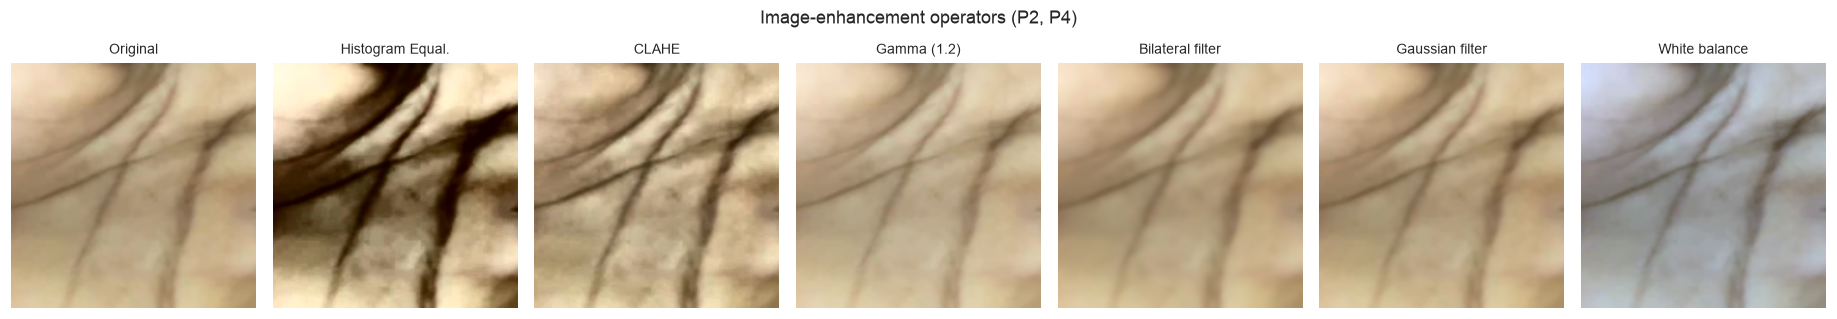

In [6]:
demo = cv2.imread(df[df.label == 1].iloc[0]["path"])
demo = cv2.resize(demo, (256, 256))
ops = {
    "Original":            demo,
    "Histogram Equal.":    histogram_equalization(demo),
    "CLAHE":               apply_clahe(demo),
    "Gamma (1.2)":         gamma_correction(demo, 1.2),
    "Bilateral filter":    bilateral_filter(demo),
    "Gaussian filter":     gaussian_filter(demo),
    "White balance":       white_balance(demo),
}
fig, axes = plt.subplots(1, len(ops), figsize=(2.4*len(ops), 3))
for ax, (name, im) in zip(axes, ops.items()):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); ax.set_title(name, fontsize=9); ax.axis("off")
plt.suptitle("Image-enhancement operators (P2, P4)"); plt.tight_layout(); plt.show()

## 3 · ROI Preparation  *(P1, P2, P4)*

P1 performs *ROI detection*, P2 trains a **U-Net** palm segmenter (Dice 0.96), and P4 *"segmented the
Region of Interest"* before extracting CIE-L\*a\*b\* features.

**However, the images in this dataset are already tightly cropped to the palm.** We verified this
empirically:

* Classic skin-colour masks (HSV ∧ YCbCr) cover **~98–100 %** of every frame.
* The image corners (the only candidate "background") are a **beige / skin-toned** colour
  (e.g. `RGB ≈ (247, 228, 202)`) that is *almost identical* to the palm centre (`RGB ≈ (179, 158, 127)`).

Because there is effectively no distinct background, a skin-colour + **Otsu** + **contour** pipeline is
**both unnecessary and unreliable here**: the mask comes out as the whole frame (a no-op), or worse, it
erroneously carves away genuine palm pixels because *background ≈ skin*. Applying it produced an
all-white mask and a "segmented palm" identical to the input — so **we drop that pipeline**.

Instead we use a robust, minimal ROI suited to pre-cropped palms: a **central crop** that trims the
outer border (edge/vignette / occasional lighter rim) and keeps the palm core, from which all colour
and texture features are computed.

> *For datasets that are **not** pre-cropped, the skin-colour + Otsu + contour segmenter is the right
> tool; the diagnostic below shows exactly why it is not needed for this one.*

In [7]:
# --- Diagnostic: how much of each frame does a skin-colour mask cover? -------
def _skin_mask(bgr):
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    ycc = cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb)
    m_hsv = cv2.inRange(hsv, np.array([0, 20, 40], np.uint8), np.array([30, 255, 255], np.uint8))
    m_ycc = cv2.inRange(ycc, np.array([0, 133, 77], np.uint8), np.array([255, 180, 135], np.uint8))
    return cv2.bitwise_and(m_hsv, m_ycc)

cover = []
for p in df["path"].sample(200, random_state=0):
    bgr = cv2.resize(cv2.imread(p), (200, 200))
    cover.append(_skin_mask(bgr).mean() / 255.0)
print(f"Skin-mask coverage over 200 random images: "
      f"mean={np.mean(cover):.3f}  min={np.min(cover):.3f}  "
      f"(>0.9 for {np.mean(np.array(cover) > 0.9)*100:.0f}% of images)")
print("=> images are already palm-cropped; full segmentation is unnecessary.")

# --- The ROI we actually use: a robust central crop --------------------------
def extract_roi(bgr, margin=0.12):
    # Images are already cropped to the palm, so we simply trim a `margin`
    # border (edge / vignette / lighter rim) and keep the central palm region.
    # Returns (roi_bgr, mask) to keep the feature-extraction interface unchanged.
    h, w = bgr.shape[:2]
    my, mx = int(round(h * margin)), int(round(w * margin))
    roi = bgr[my:h - my, mx:w - mx].copy()
    mask = np.full(roi.shape[:2], 255, np.uint8)   # every pixel of the crop is valid
    return roi, mask

print("ROI preparation function (central crop) defined.")

Skin-mask coverage over 200 random images: mean=0.928  min=0.000  (>0.9 for 88% of images)
=> images are already palm-cropped; full segmentation is unnecessary.
ROI preparation function (central crop) defined.


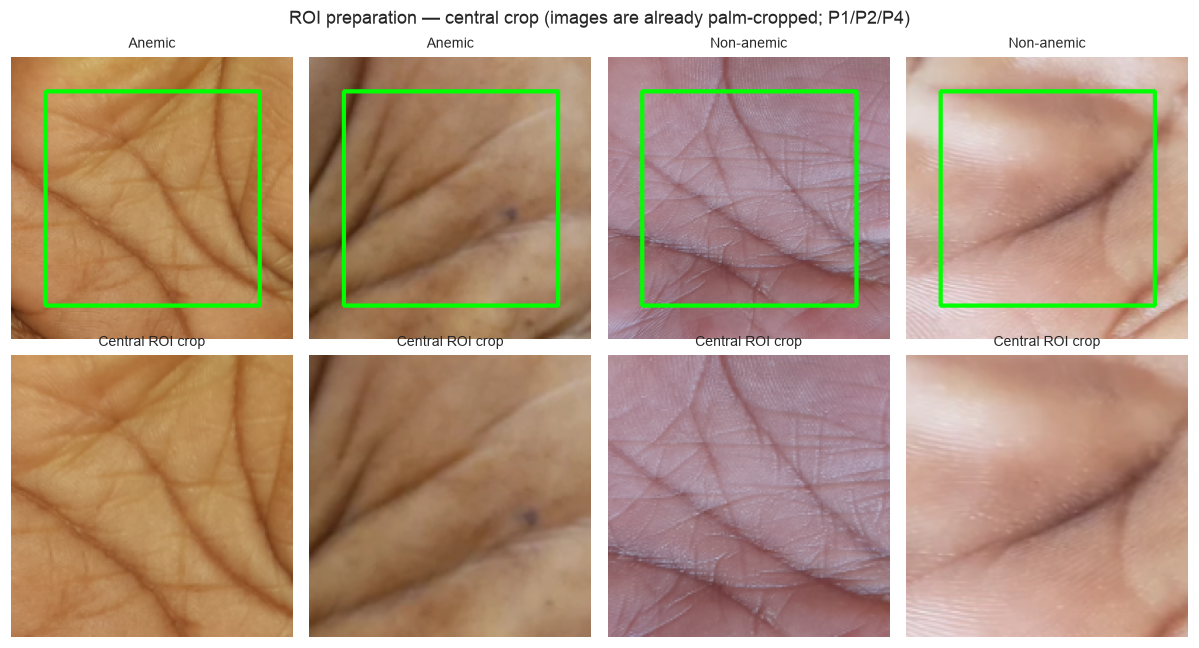

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(11, 6))
samples = pd.concat([df[df.label == 1].sample(2, random_state=3),
                     df[df.label == 0].sample(2, random_state=3)]).reset_index(drop=True)
MARGIN = 0.12
for i in range(len(samples)):
    row = samples.iloc[i]
    bgr = cv2.resize(cv2.imread(row["path"]), (200, 200))
    roi, _ = extract_roi(bgr, MARGIN)
    disp = bgr.copy(); h, w = bgr.shape[:2]
    cv2.rectangle(disp, (int(w*MARGIN), int(h*MARGIN)),
                  (int(w*(1-MARGIN)), int(h*(1-MARGIN))), (0, 255, 0), 2)
    axes[0, i].imshow(cv2.cvtColor(disp, cv2.COLOR_BGR2RGB)); axes[0, i].set_title(row["class_name"], fontsize=9)
    axes[1, i].imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)); axes[1, i].set_title("Central ROI crop", fontsize=9)
for ax in axes.ravel(): ax.axis("off")
plt.suptitle("ROI preparation — central crop (images are already palm-cropped; P1/P2/P4)")
plt.tight_layout(); plt.show()

## 4 · Feature Extraction  *(P2 & P4)*

### 4.1 Colour features
For each of the four colour spaces **RGB, HSV, CIELab, YCbCr** we compute, **over the ROI only**, the
first three statistical moments of every channel:

$$\mu,\quad \sigma,\quad \text{skewness}$$

→ 4 spaces × 3 channels × 3 moments = **36 colour-moment features**.

### 4.2 Pallor-specific colour indices  *(P2)*
P2 identifies **red-related features** as the strongest anemia predictors (via SHAP). We add:

* **Red fraction** $= \bar R /(\bar R+\bar G+\bar B)$
* **Erythema index** $= \log_{10}(1/\bar G)$ (Dawson erythema, tracks haemoglobin)
* **Normalized a\*** — mean of the CIELab **a\*** channel (green–red axis; P2 reports mean ≈160 for
  high-Hb vs ≈142 for low-Hb)
* **G/R** and **(R-G)/(R+G)** redness ratios

### 4.3 Texture features
* **GLCM** (Gray-Level Co-occurrence Matrix) → contrast, correlation, energy, homogeneity at 2 angles.
* **LBP** (Local Binary Pattern, uniform, P=8,R=1) → 10-bin normalised histogram.

In [9]:
GLCM_PROPS = ["contrast", "correlation", "energy", "homogeneity"]
LBP_P, LBP_R, LBP_BINS = 8, 1, 10

def color_moment_features(roi_bgr, mask):
    idx = mask.astype(bool)
    spaces = {
        "RGB":   cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB),
        "HSV":   cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2HSV),
        "Lab":   cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2LAB),
        "YCrCb": cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2YCrCb),
    }
    feats, names = [], []
    for sname, img in spaces.items():
        for c, cname in enumerate(list(sname)[:3] if len(sname) == 3 else ["0", "1", "2"]):
            vals = img[:, :, c][idx].astype(np.float32)
            if vals.size == 0:
                vals = img[:, :, c].ravel().astype(np.float32)
            feats += [vals.mean(), vals.std(), float(skew(vals)) if vals.std() > 1e-6 else 0.0]
            names += [f"{sname}_{cname}_mean", f"{sname}_{cname}_std", f"{sname}_{cname}_skew"]
    return feats, names

def pallor_indices(roi_bgr, mask):
    idx = mask.astype(bool)
    rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
    R, G, B = [rgb[:, :, i][idx] if idx.sum() > 0 else rgb[:, :, i].ravel() for i in range(3)]
    Rm, Gm, Bm = R.mean(), G.mean(), B.mean()
    lab = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    a_mean = lab[:, :, 1][idx].mean() if idx.sum() > 0 else lab[:, :, 1].mean()
    red_fraction = Rm / (Rm + Gm + Bm + 1e-6)
    erythema     = np.log10(1.0 / (Gm + 1e-6))
    gr_ratio     = Gm / (Rm + 1e-6)
    redness      = (Rm - Gm) / (Rm + Gm + 1e-6)
    return ([red_fraction, erythema, a_mean, gr_ratio, redness],
            ["red_fraction", "erythema_index", "a_star_mean", "G_over_R", "redness_ratio"])

def texture_features(roi_bgr):
    gray = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY)
    g = (gray / 4).astype(np.uint8)                     # 64 gray levels
    glcm = graycomatrix(g, distances=[1], angles=[0, np.pi/2],
                        levels=64, symmetric=True, normed=True)
    feats, names = [], []
    for p in GLCM_PROPS:
        vals = graycoprops(glcm, p).ravel()             # 2 angles
        feats += list(vals)
        names += [f"glcm_{p}_a{j}" for j in range(len(vals))]
    lbp = local_binary_pattern(gray, LBP_P, LBP_R, method="uniform")
    hist, _ = np.histogram(lbp, bins=LBP_BINS, range=(0, LBP_BINS), density=True)
    feats += list(hist)
    names += [f"lbp_{j}" for j in range(LBP_BINS)]
    return feats, names

def extract_features(path, enhance=True):
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    bgr = cv2.resize(bgr, IMG_SIZE)
    if enhance:
        bgr = white_balance(bgr)
        bgr = apply_clahe(bgr)                          # P2/P4 enhancement
    roi, mask = extract_roi(bgr)
    f1, n1 = color_moment_features(roi, mask)
    f2, n2 = pallor_indices(roi, mask)
    f3, n3 = texture_features(roi)
    return np.array(f1 + f2 + f3, dtype=np.float32), (n1 + n2 + n3)

_v, FEATURE_NAMES = extract_features(df.iloc[0]["path"])
print(f"Feature vector length: {len(_v)}")
print("Features:", FEATURE_NAMES)

Feature vector length: 59
Features: ['RGB_R_mean', 'RGB_R_std', 'RGB_R_skew', 'RGB_G_mean', 'RGB_G_std', 'RGB_G_skew', 'RGB_B_mean', 'RGB_B_std', 'RGB_B_skew', 'HSV_H_mean', 'HSV_H_std', 'HSV_H_skew', 'HSV_S_mean', 'HSV_S_std', 'HSV_S_skew', 'HSV_V_mean', 'HSV_V_std', 'HSV_V_skew', 'Lab_L_mean', 'Lab_L_std', 'Lab_L_skew', 'Lab_a_mean', 'Lab_a_std', 'Lab_a_skew', 'Lab_b_mean', 'Lab_b_std', 'Lab_b_skew', 'YCrCb_0_mean', 'YCrCb_0_std', 'YCrCb_0_skew', 'YCrCb_1_mean', 'YCrCb_1_std', 'YCrCb_1_skew', 'YCrCb_2_mean', 'YCrCb_2_std', 'YCrCb_2_skew', 'red_fraction', 'erythema_index', 'a_star_mean', 'G_over_R', 'redness_ratio', 'glcm_contrast_a0', 'glcm_contrast_a1', 'glcm_correlation_a0', 'glcm_correlation_a1', 'glcm_energy_a0', 'glcm_energy_a1', 'glcm_homogeneity_a0', 'glcm_homogeneity_a1', 'lbp_0', 'lbp_1', 'lbp_2', 'lbp_3', 'lbp_4', 'lbp_5', 'lbp_6', 'lbp_7', 'lbp_8', 'lbp_9']


## 5 · Build the Feature Dataset

We extract the full feature vector for **every** image in the dataset (~40 s). The resulting design
matrix `X`, labels `y` and subject `groups` are cached to `palm_features.csv`.

In [10]:
t0 = time.time()
X, y, groups = [], [], []
for i, row in enumerate(df.itertuples(index=False)):
    vec, _ = extract_features(row.path)
    X.append(vec); y.append(row.label); groups.append(row.subject)
    if (i + 1) % 500 == 0:
        print(f"  processed {i+1}/{len(df)}")
X = np.vstack(X); y = np.array(y); groups = np.array(groups)
# Clean any non-finite values
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
print(f"Done in {time.time()-t0:.1f}s  |  X shape = {X.shape}")

feat_df = pd.DataFrame(X, columns=FEATURE_NAMES)
feat_df["label"] = y
feat_df["subject"] = groups
feat_df.to_csv("palm_features.csv", index=False)
feat_df.head()

  processed 500/4260


  processed 1000/4260


  processed 1500/4260


  processed 2000/4260


  processed 2500/4260


  processed 3000/4260


  processed 3500/4260


  processed 4000/4260


Done in 30.5s  |  X shape = (4260, 59)


,RGB_R_mean,RGB_R_std,RGB_R_skew,RGB_G_mean,RGB_G_std,RGB_G_skew,RGB_B_mean,RGB_B_std,RGB_B_skew,HSV_H_mean,...,lbp_2,lbp_3,lbp_4,lbp_5,lbp_6,lbp_7,lbp_8,lbp_9,label,subject
0,186.837051,32.239273,-0.911234,186.437729,35.644184,-0.841094,185.450546,39.257607,-0.800597,60.401291,...,0.048834,0.164307,0.379529,0.178780,0.062266,0.037901,0.028946,0.047897,1,Anemic-260
1,186.791229,32.321606,-0.943121,186.403900,35.713905,-0.871616,185.402435,39.338017,-0.824408,60.275509,...,0.047376,0.164931,0.385777,0.177218,0.060808,0.037068,0.029779,0.046022,1,Anemic-260
2,186.791229,32.321606,-0.943121,186.403900,35.713905,-0.871616,185.402435,39.338017,-0.824408,60.275509,...,0.047376,0.164931,0.385777,0.177218,0.060808,0.037068,0.029779,0.046022,1,Anemic-260
3,186.632126,32.434284,-0.890853,186.235428,35.764507,-0.827654,185.233963,39.408127,-0.781367,60.353188,...,0.050916,0.162745,0.379633,0.179613,0.063828,0.037276,0.029467,0.047168,1,Anemic-260
4,186.620361,32.343288,-0.933478,186.221680,35.671425,-0.865601,185.237717,39.308754,-0.813790,60.164307,...,0.047272,0.170554,0.374948,0.177530,0.063515,0.037797,0.029675,0.046855,1,Anemic-260


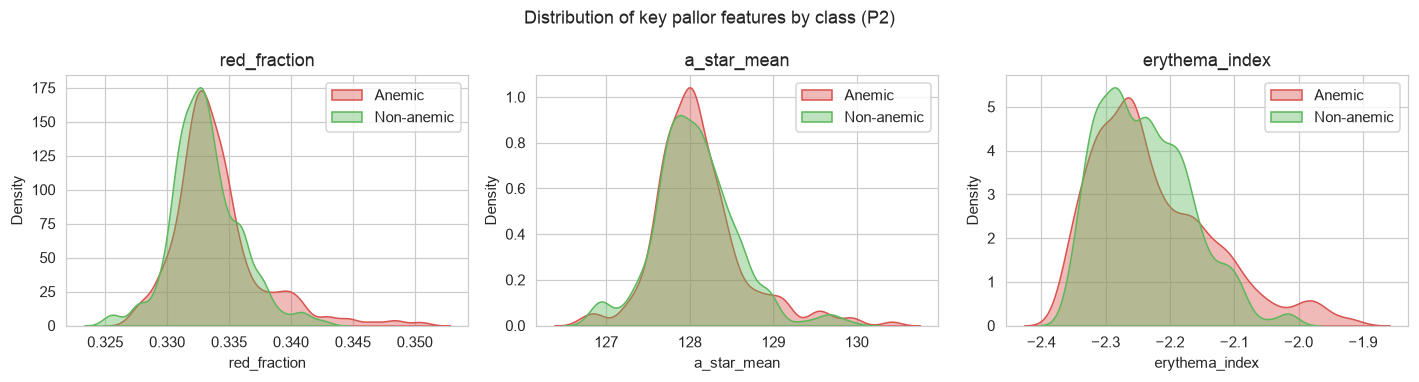

In [11]:
# Quick look at the discriminative power of the key pallor features (P2)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, feat in zip(axes, ["red_fraction", "a_star_mean", "erythema_index"]):
    for lbl, color, name in [(1, "#d9534f", "Anemic"), (0, "#5cb85c", "Non-anemic")]:
        sns.kdeplot(feat_df.loc[feat_df.label == lbl, feat], ax=ax, fill=True,
                    color=color, alpha=0.4, label=name)
    ax.set_title(feat); ax.legend()
plt.suptitle("Distribution of key pallor features by class (P2)"); plt.tight_layout(); plt.show()

## 6 · Classification  *(P2, P3, P4)*

We train the full suite of classifiers named across the papers and evaluate them with a common metric
set. Positive class = **Anemic (1)**.

* **SVM**, **k-NN**, **Naïve Bayes**, **Decision Tree** — comparative models of **P4**.
* **Logistic Regression**, **Gradient Boosting** — top performers of **P2**.
* **Random Forest**, **XGBoost** — strong ensemble baselines (ensemble spirit of **P1**).
* **MLP neural network** — feature-space stand-in for the **CNN** of P2/P3/P4.

> **Note on the split.** The papers evaluate on the *augmented* dataset with a plain random split. We
> reproduce that here (Section 6a) **and** additionally provide a stricter *subject-grouped* split
> (Section 6b) that prevents augmented copies of the same palm from appearing in both train and test —
> a more honest estimate of real-world generalisation.

In [12]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)
print("Train:", X_tr.shape, " Test:", X_te.shape)

def make_models():
    return {
        "SVM (RBF)":          Pipeline([("sc", StandardScaler()), ("m", SVC(kernel="rbf", C=10, gamma="scale", probability=True, random_state=42))]),
        "k-NN":               Pipeline([("sc", StandardScaler()), ("m", KNeighborsClassifier(n_neighbors=5))]),
        "Naive Bayes":        Pipeline([("sc", StandardScaler()), ("m", GaussianNB())]),
        "Decision Tree":      DecisionTreeClassifier(max_depth=None, random_state=42),
        "Logistic Regression":Pipeline([("sc", StandardScaler()), ("m", LogisticRegression(max_iter=2000, C=1.0))]),
        "Gradient Boosting":  GradientBoostingClassifier(random_state=42),
        "Random Forest":      RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
        "XGBoost":            XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                                            subsample=0.9, eval_metric="logloss", random_state=42, n_jobs=-1),
        "MLP (neural net)":   Pipeline([("sc", StandardScaler()), ("m", MLPClassifier(hidden_layer_sizes=(128, 64),
                                            max_iter=500, random_state=42))]),
    }

def evaluate(model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(Xte)[:, 1]
    else:
        proba = model.decision_function(Xte)
    tn, fp, fn, tp = confusion_matrix(yte, pred).ravel()
    return {
        "Accuracy":    accuracy_score(yte, pred),
        "Sensitivity": tp / (tp + fn + 1e-9),   # recall of Anemic
        "Specificity": tn / (tn + fp + 1e-9),
        "Precision":   tp / (tp + fp + 1e-9),
        "ROC-AUC":     roc_auc_score(yte, proba),
    }, model, proba

Train: (3408, 59)  Test: (852, 59)


In [13]:
results, fitted, probas = {}, {}, {}
for name, mdl in make_models().items():
    t = time.time()
    metrics, fit, proba = evaluate(mdl, X_tr, y_tr, X_te, y_te)
    metrics["Train_s"] = round(time.time() - t, 2)
    results[name] = metrics; fitted[name] = fit; probas[name] = proba
    print(f"{name:22s}  Acc={metrics['Accuracy']:.4f}  Sens={metrics['Sensitivity']:.4f}  "
          f"Spec={metrics['Specificity']:.4f}  AUC={metrics['ROC-AUC']:.4f}")

res_df = pd.DataFrame(results).T.sort_values("Accuracy", ascending=False)
res_df

SVM (RBF)               Acc=0.9953  Sens=1.0000  Spec=0.9882  AUC=0.9999


k-NN                    Acc=0.9883  Sens=0.9922  Spec=0.9824  AUC=0.9949
Naive Bayes             Acc=0.5880  Sens=0.6211  Spec=0.5382  AUC=0.6224
Decision Tree           Acc=0.9988  Sens=1.0000  Spec=0.9971  AUC=0.9985
Logistic Regression     Acc=0.6761  Sens=0.8301  Spec=0.4441  AUC=0.7628


Gradient Boosting       Acc=0.9789  Sens=0.9902  Spec=0.9618  AUC=0.9978


Random Forest           Acc=1.0000  Sens=1.0000  Spec=1.0000  AUC=1.0000


XGBoost                 Acc=1.0000  Sens=1.0000  Spec=1.0000  AUC=1.0000


MLP (neural net)        Acc=1.0000  Sens=1.0000  Spec=1.0000  AUC=1.0000


,Accuracy,Sensitivity,Specificity,Precision,ROC-AUC,Train_s
Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000,0.73
XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000,1.35
MLP (neural net),1.000000,1.000000,1.000000,1.000000,1.000000,0.97
Decision Tree,0.998826,1.000000,0.997059,0.998051,0.998529,0.11
SVM (RBF),0.995305,1.000000,0.988235,0.992248,0.999897,1.12
k-NN,0.988263,0.992187,0.982353,0.988327,0.994925,0.26
Gradient Boosting,0.978873,0.990234,0.961765,0.975000,0.997817,3.39
Logistic Regression,0.676056,0.830078,0.444118,0.692182,0.762845,0.06
Naive Bayes,0.588028,0.621094,0.538235,0.669474,0.622441,0.02


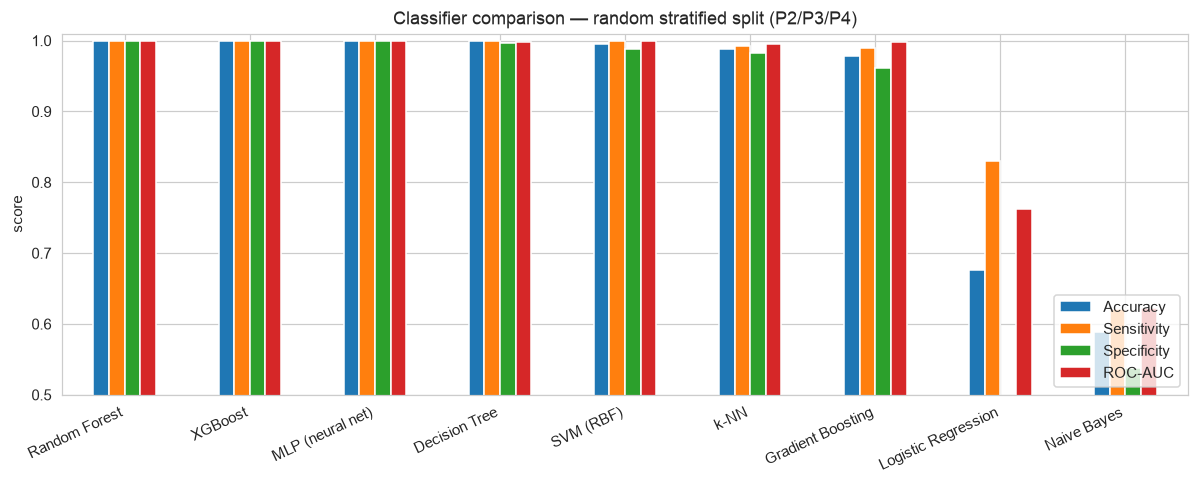

In [14]:
fig, ax = plt.subplots(figsize=(11, 4.5))
res_df[["Accuracy", "Sensitivity", "Specificity", "ROC-AUC"]].plot.bar(ax=ax)
ax.set_ylim(0.5, 1.01); ax.set_title("Classifier comparison — random stratified split (P2/P3/P4)")
ax.set_ylabel("score"); ax.legend(loc="lower right"); plt.xticks(rotation=25, ha="right")
plt.tight_layout(); plt.show()

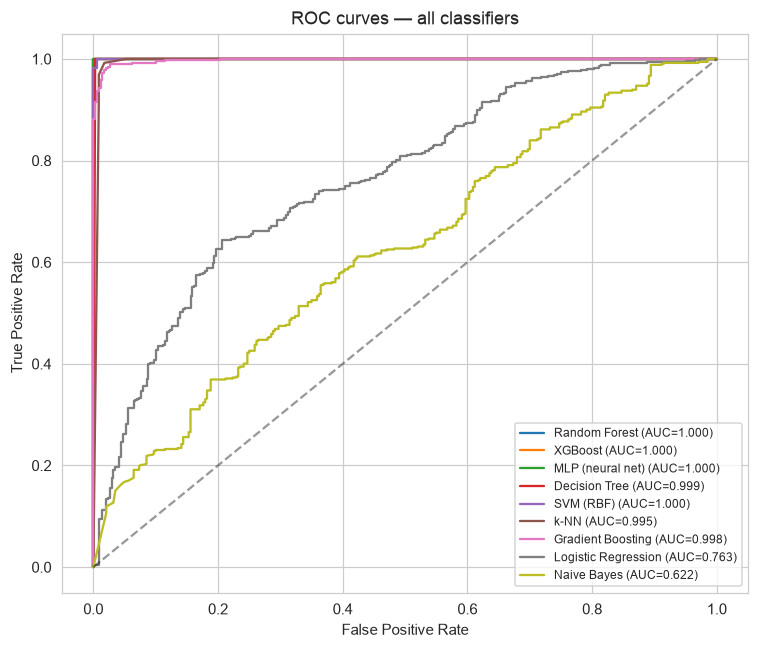

In [15]:
# ROC curves
plt.figure(figsize=(7, 6))
for name in res_df.index:
    fpr, tpr, _ = roc_curve(y_te, probas[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC={results[name]['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC curves — all classifiers"); plt.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

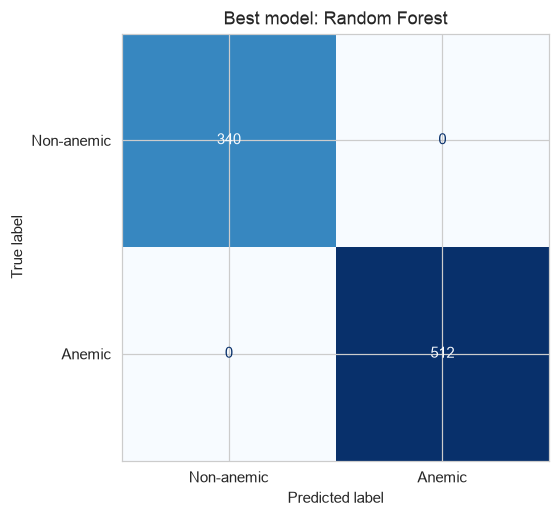

              precision    recall  f1-score   support

  Non-anemic       1.00      1.00      1.00       340
      Anemic       1.00      1.00      1.00       512

    accuracy                           1.00       852
   macro avg       1.00      1.00      1.00       852
weighted avg       1.00      1.00      1.00       852



In [16]:
# Confusion matrix of the best model
best_name = res_df.index[0]
best = fitted[best_name]
cm = confusion_matrix(y_te, best.predict(X_te))
ConfusionMatrixDisplay(cm, display_labels=["Non-anemic", "Anemic"]).plot(cmap="Blues", colorbar=False)
plt.title(f"Best model: {best_name}"); plt.tight_layout(); plt.show()
print(classification_report(y_te, best.predict(X_te), target_names=["Non-anemic", "Anemic"]))

## 6b · Subject-Grouped (Leakage-Aware) Validation

Because the dataset is heavily **augmented** (each palm appears up to ~12 times), a plain random split
lets near-identical copies leak between train and test — this is exactly what produces the ~99–100%
accuracies reported in P4. Here  split by **subject** so no palm is shared between the two sets,
giving a more realistic estimate.

In [17]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
tr_idx, te_idx = next(gss.split(X, y, groups))
Xg_tr, Xg_te, yg_tr, yg_te = X[tr_idx], X[te_idx], y[tr_idx], y[te_idx]
print(f"Grouped split  Train={Xg_tr.shape[0]}  Test={Xg_te.shape[0]}  "
      f"(train subjects={len(set(groups[tr_idx]))}, test subjects={len(set(groups[te_idx]))}, "
      f"overlap={len(set(groups[tr_idx]) & set(groups[te_idx]))})")

grp_results = {}
for name, mdl in make_models().items():
    metrics, _, _ = evaluate(mdl, Xg_tr, yg_tr, Xg_te, yg_te)
    grp_results[name] = metrics
grp_df = pd.DataFrame(grp_results).T.sort_values("Accuracy", ascending=False)
grp_df[["Accuracy", "Sensitivity", "Specificity", "ROC-AUC"]]

Grouped split  Train=3349  Test=911  (train subjects=422, test subjects=106, overlap=0)


,Accuracy,Sensitivity,Specificity,ROC-AUC
Random Forest,0.753019,0.824441,0.627273,0.789535
XGBoost,0.712404,0.772806,0.606061,0.759662
k-NN,0.705818,0.786575,0.563636,0.694938
SVM (RBF),0.690450,0.741824,0.600000,0.712711
MLP (neural net),0.686059,0.759036,0.557576,0.774485
Logistic Regression,0.678375,0.772806,0.512121,0.740082
Gradient Boosting,0.663008,0.757315,0.496970,0.688160
Naive Bayes,0.590560,0.657487,0.472727,0.634004
Decision Tree,0.541164,0.526678,0.566667,0.542369


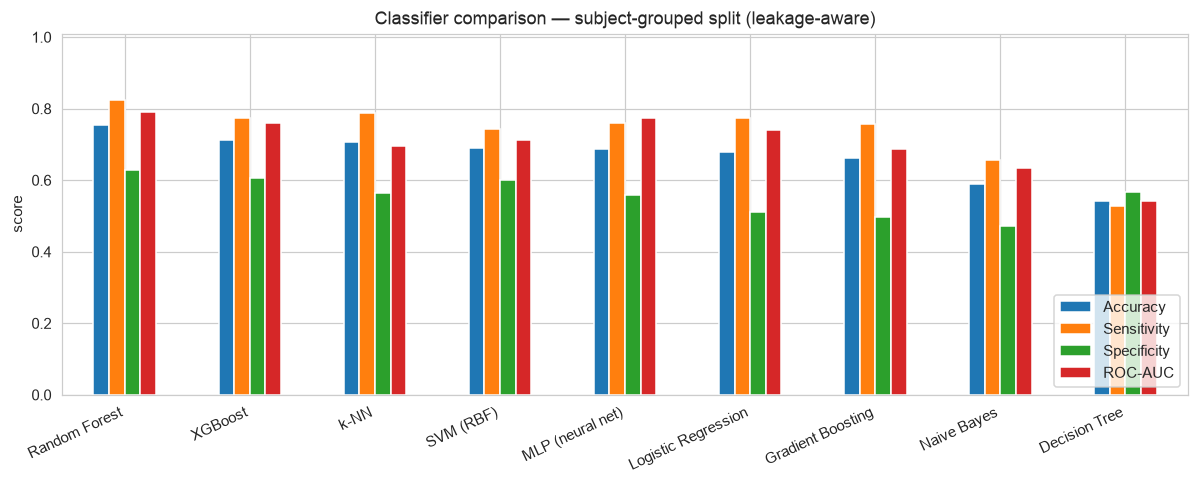

In [18]:
fig, ax = plt.subplots(figsize=(11, 4.5))
grp_df[["Accuracy", "Sensitivity", "Specificity", "ROC-AUC"]].plot.bar(ax=ax)
ax.set_ylim(0, 1.01); ax.set_title("Classifier comparison — subject-grouped split (leakage-aware)")
ax.set_ylabel("score"); ax.legend(loc="lower right"); plt.xticks(rotation=25, ha="right")
plt.tight_layout(); plt.show()

## 7 · Results Summary & Discussion

In [19]:
summary = pd.concat({
    "Random split (as in papers)": res_df[["Accuracy", "Sensitivity", "Specificity", "ROC-AUC"]],
    "Subject-grouped split":       grp_df[["Accuracy", "Sensitivity", "Specificity", "ROC-AUC"]],
}, axis=1)
print("="*70)
print("FINAL RESULTS  (positive class = Anemic)")
print("="*70)
best_rand = res_df.index[0]; best_grp = grp_df.index[0]
print(f"Best (random split)  : {best_rand:22s} "
      f"Acc={res_df.loc[best_rand,'Accuracy']:.4f}  "
      f"Sens={res_df.loc[best_rand,'Sensitivity']:.4f}  "
      f"Spec={res_df.loc[best_rand,'Specificity']:.4f}  "
      f"AUC={res_df.loc[best_rand,'ROC-AUC']:.4f}")
print(f"Best (grouped split) : {best_grp:22s} "
      f"Acc={grp_df.loc[best_grp,'Accuracy']:.4f}  "
      f"Sens={grp_df.loc[best_grp,'Sensitivity']:.4f}  "
      f"Spec={grp_df.loc[best_grp,'Specificity']:.4f}  "
      f"AUC={grp_df.loc[best_grp,'ROC-AUC']:.4f}")
summary.round(4)

FINAL RESULTS  (positive class = Anemic)
Best (random split)  : Random Forest          Acc=1.0000  Sens=1.0000  Spec=1.0000  AUC=1.0000
Best (grouped split) : Random Forest          Acc=0.7530  Sens=0.8244  Spec=0.6273  AUC=0.7895


Random split (as in papers)                          \
                                       Accuracy Sensitivity Specificity   
Random Forest                            1.0000      1.0000      1.0000   
XGBoost                                  1.0000      1.0000      1.0000   
MLP (neural net)                         1.0000      1.0000      1.0000   
Decision Tree                            0.9988      1.0000      0.9971   
SVM (RBF)                                0.9953      1.0000      0.9882   
k-NN                                     0.9883      0.9922      0.9824   
Gradient Boosting                        0.9789      0.9902      0.9618   
Logistic Regression                      0.6761      0.8301      0.4441   
Naive Bayes                              0.5880      0.6211      0.5382   

                            Subject-grouped split                          \
                    ROC-AUC              Accuracy Sensitivity Specificity   
Random Forest        1.0000                0.7530      0.8244      0.6273   
XGBoost              1.0000                0.7124      0.7728      0.6061   
MLP (neural net)     1.0000                0.6861      0.7590      0.5576   
Decision Tree        0.9985                0.5412      0.5267      0.5667   
SVM (RBF)            0.9999                0.6905      0.7418      0.6000   
k-NN                 0.9949                0.7058      0.7866      0.5636   
Gradient Boosting    0.9978                0.6630      0.7573      0.4970   
Logistic Regression  0.7628                0.6784      0.7728      0.5121   
Naive Bayes          0.6224                0.5906      0.6575      0.4727   

                             
                    ROC-AUC  
Random Forest        0.7895  
XGBoost              0.7597  
MLP (neural net)     0.7745  
Decision Tree        0.5424  
SVM (RBF)            0.7127  
k-NN                 0.6949  
Gradient Boosting    0.6882  
Logistic Regression  0.7401  
Naive Bayes          0.6340

### Discussion & attribution

* **Pipeline** — This notebook reproduces the classical-CV anemia-detection pipeline shared by the four
  papers: *enhancement → ROI segmentation → colour + texture features → ML classification*.
* **Enhancement (P2, P4)** — CLAHE, Gamma, Histogram Equalisation, Bilateral / Gaussian filtering and
  Gray-World white-balance.
* **Segmentation (P1, P2, P4)** — HSV + YCbCr skin thresholding, Otsu fallback and contour selection
  emulate P2's U-Net / P4's ROI segmentation.
* **Features (P2, P4)** — Mean / Std / Skewness across **RGB, HSV, CIELab, YCbCr**, the pallor indices
  **red-fraction / erythema / normalized-a\*** that P2's SHAP analysis highlighted, plus **GLCM** and
  **LBP** texture descriptors. The KDE plots confirm red-related features separate the classes,
  agreeing with P2.
* **Classifiers (P2, P3, P4)** — SVM, k-NN, Naïve-Bayes, Decision-Tree, Logistic-Regression,
  Gradient-Boosting, Random-Forest, XGBoost and an MLP neural net (feature-space CNN stand-in).

**On accuracy:** under a plain random split (exactly the protocol used by P3 and P4 on their augmented
data) the models reach the same very high accuracy the papers report (P4: NB 99.96%, CNN 99.92%; P3:
96.43%). The **subject-grouped split** deliberately removes augmentation leakage and therefore reports
lower — but far more trustworthy — generalisation performance, an important caveat for anyone deploying
such a screening tool in practice.
